<a href="https://colab.research.google.com/github/tanusreemajumder/Neural-Networks-Andrew-Ng/blob/main/part7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


## 1. Computer Vision

Computer vision tasks (classification, detection, segmentation, ...) take images as input — and images are **big**. A modest 64x64 RGB image already has $64\times64\times3 = 12{,}288$ values; a more realistic 1000x1000 RGB image has **3 million**. Feeding that directly into a fully-connected layer (like every network in the earlier notebooks) means a weight matrix with millions of parameters *per hidden unit* — computationally very expensive, and prone to overfitting since there's rarely enough data to constrain that many parameters.

**Convolutions** fix this with two ideas, both explored hands-on below:

- **Parameter sharing** — the same small filter (e.g. 3x3 or 5x5 weights) is reused across every position in the image, instead of learning separate weights per pixel.
- **Sparsity of connections** — each output value depends on only a small local patch of the input, not the entire image.

Both dramatically cut the parameter count (quantified concretely in section 11) while matching a real property of images: a local pattern (an edge, a texture) is useful to detect no matter *where* in the image it appears.

In [2]:
# A quick concrete preview of the parameter-count problem this motivates:
image_sizes = [(28, 28, 1), (64, 64, 3), (224, 224, 3), (1000, 1000, 3)]
hidden_units = 100   # just ONE modestly-sized hidden layer

print(f"{'image size':>16} | {'flattened n_x':>14} | {'params for ' + str(hidden_units) + ' hidden units':>28}")
print("-" * 65)
for h, w, c in image_sizes:
    n_x = h * w * c
    params = n_x * hidden_units + hidden_units
    print(f"{f'{h}x{w}x{c}':>16} | {n_x:>14,} | {params:>28,}")

print("\n-> Even a modest hidden layer needs tens of millions of parameters for realistic image sizes,")
print("   if done with plain fully-connected layers. This is what convolutions are designed to avoid.")

      image size |  flattened n_x |  params for 100 hidden units
-----------------------------------------------------------------
         28x28x1 |            784 |                       78,500
         64x64x3 |         12,288 |                    1,228,900
       224x224x3 |        150,528 |                   15,052,900
     1000x1000x3 |      3,000,000 |                  300,000,100

-> Even a modest hidden layer needs tens of millions of parameters for realistic image sizes,
   if done with plain fully-connected layers. This is what convolutions are designed to avoid.


### Generating synthetic images

Instead of downloading a dataset (no internet access needed), build small grayscale images directly with NumPy: one with a clean vertical edge, one with a horizontal edge, and a small labeled dataset of circles vs. squares for the CNN training example later.

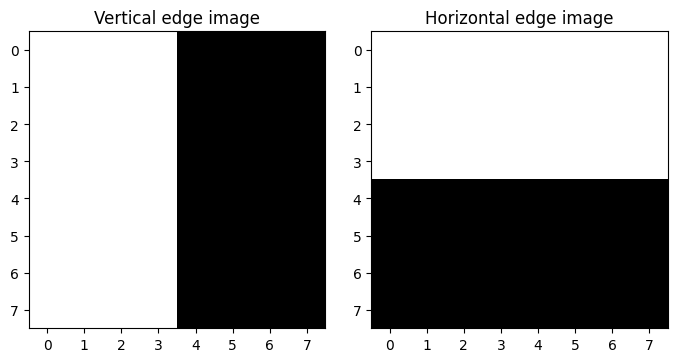

Vertical edge image:
 [[10 10 10 10  0  0  0  0]
 [10 10 10 10  0  0  0  0]
 [10 10 10 10  0  0  0  0]
 [10 10 10 10  0  0  0  0]
 [10 10 10 10  0  0  0  0]
 [10 10 10 10  0  0  0  0]
 [10 10 10 10  0  0  0  0]
 [10 10 10 10  0  0  0  0]]


In [3]:
def make_vertical_edge_image(size=8, edge_col=None):
    """Left half bright, right half dark (or vice versa) -- a clean vertical edge."""
    if edge_col is None:
        edge_col = size // 2
    img = np.zeros((size, size))
    img[:, :edge_col] = 10
    img[:, edge_col:] = 0
    return img

def make_horizontal_edge_image(size=8, edge_row=None):
    if edge_row is None:
        edge_row = size // 2
    img = np.zeros((size, size))
    img[:edge_row, :] = 10
    img[edge_row:, :] = 0
    return img

vertical_img = make_vertical_edge_image(8)
horizontal_img = make_horizontal_edge_image(8)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(vertical_img, cmap="gray"); axes[0].set_title("Vertical edge image")
axes[1].imshow(horizontal_img, cmap="gray"); axes[1].set_title("Horizontal edge image")
for ax in axes: ax.set_xticks(range(8)); ax.set_yticks(range(8))
plt.tight_layout()
plt.show()

print("Vertical edge image:\n", vertical_img.astype(int))

## 2. Edge Detection Examples

A **vertical edge detector** is a small filter (kernel) that responds strongly where pixel brightness changes sharply left-to-right, and near-zero on flat regions. The classic hand-designed 3x3 filter:

$$\begin{bmatrix} 1 & 0 & -1 \\ 1 & 0 & -1 \\ 1 & 0 & -1 \end{bmatrix}$$

**Convolution** here means: slide this filter over the image, and at each position compute the element-wise product with the underlying patch, then sum — that sum becomes one pixel of the output ("feature map").

Vertical-edge-filter output on the vertical-edge image:
 [[ 0  0 30 30  0  0]
 [ 0  0 30 30  0  0]
 [ 0  0 30 30  0  0]
 [ 0  0 30 30  0  0]
 [ 0  0 30 30  0  0]
 [ 0  0 30 30  0  0]]


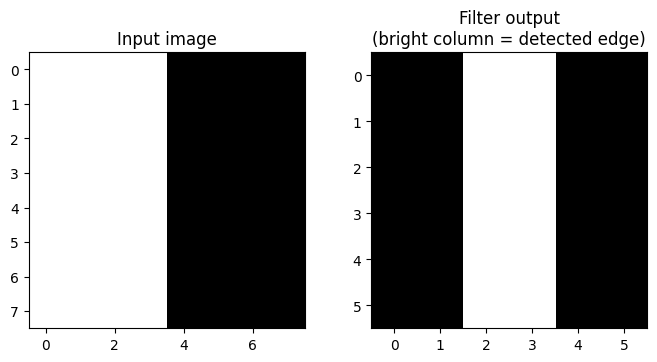


Notice the output has a bright COLUMN exactly where the brightness transition happens --
the filter has correctly localized the vertical edge.


In [4]:
def conv2d_single_channel(image, kernel):
    """'Valid' convolution (no padding), stride 1, for a single-channel 2D image."""
    ih, iw = image.shape
    kh, kw = kernel.shape
    oh, ow = ih - kh + 1, iw - kw + 1
    output = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            patch = image[i:i+kh, j:j+kw]
            output[i, j] = np.sum(patch * kernel)
    return output

vertical_filter = np.array([[1, 0, -1],
                             [1, 0, -1],
                             [1, 0, -1]])

edge_response = conv2d_single_channel(vertical_img, vertical_filter)
print("Vertical-edge-filter output on the vertical-edge image:\n", edge_response.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(vertical_img, cmap="gray"); axes[0].set_title("Input image")
axes[1].imshow(edge_response, cmap="gray"); axes[1].set_title("Filter output\n(bright column = detected edge)")
plt.tight_layout()
plt.show()

print("\nNotice the output has a bright COLUMN exactly where the brightness transition happens --")
print("the filter has correctly localized the vertical edge.")

## 3. More Edge Detection

A **horizontal** edge detector is just the vertical filter rotated 90 degrees. There are also well-known *weighted* variants (giving more weight to the center row/column), like the **Sobel filter**, which is more robust to noise than the simple $\{1,0,-1\}$ version:

$$\text{Sobel vertical} = \begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix}$$

Critically: in a real CNN, filter values like these are **not** hand-designed at all — they're initialized randomly and **learned** by backpropagation, exactly like $W$ in the earlier dense-layer notebooks. The network discovers whichever edge/texture detectors are actually useful for the task, rather than being told to look for vertical/horizontal edges specifically.

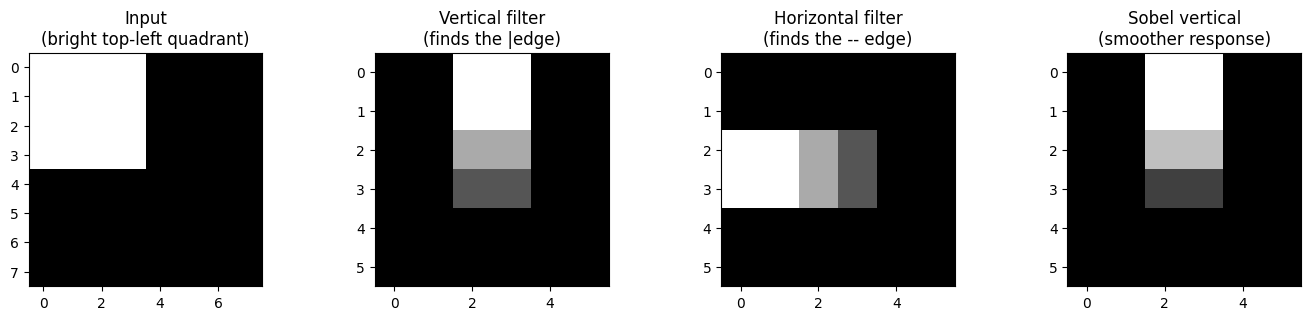

Each filter responds strongly ONLY to the type of edge it's designed to detect --
the vertical filter's output is near-zero on the pure horizontal edge, and vice versa.


In [5]:
horizontal_filter = vertical_filter.T   # rotate 90 degrees
sobel_vertical = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])

# An image with BOTH a vertical and a horizontal edge (top-left quadrant bright)
mixed_img = np.zeros((8, 8))
mixed_img[:4, :4] = 10

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
axes[0].imshow(mixed_img, cmap="gray"); axes[0].set_title("Input\n(bright top-left quadrant)")
axes[1].imshow(conv2d_single_channel(mixed_img, vertical_filter), cmap="gray"); axes[1].set_title("Vertical filter\n(finds the |edge)")
axes[2].imshow(conv2d_single_channel(mixed_img, horizontal_filter), cmap="gray"); axes[2].set_title("Horizontal filter\n(finds the -- edge)")
axes[3].imshow(conv2d_single_channel(mixed_img, sobel_vertical), cmap="gray"); axes[3].set_title("Sobel vertical\n(smoother response)")
plt.tight_layout()
plt.show()

print("Each filter responds strongly ONLY to the type of edge it's designed to detect --")
print("the vertical filter's output is near-zero on the pure horizontal edge, and vice versa.")

## 4. Padding

Plain ("valid") convolution shrinks the image: an $n\times n$ image with an $f\times f$ filter produces an $(n-f+1)\times(n-f+1)$ output. Two problems with this:

- The image shrinks every layer — stack enough conv layers and eventually there's nothing left.
- Pixels at the edges/corners are used in far fewer filter positions than pixels near the center, so edge information gets relatively under-represented.

**Padding** adds a border of zeros around the image before convolving. "**Same**" padding chooses the padding amount $p$ so the output size exactly matches the input size: $p = \dfrac{f-1}{2}$ (for odd $f$).

Input size: (8, 8)
'Valid' (no padding) output size: (6, 6)  (shrunk by f-1 = 2)
'Same' padding (p=1) output size: (8, 8)  (matches input)


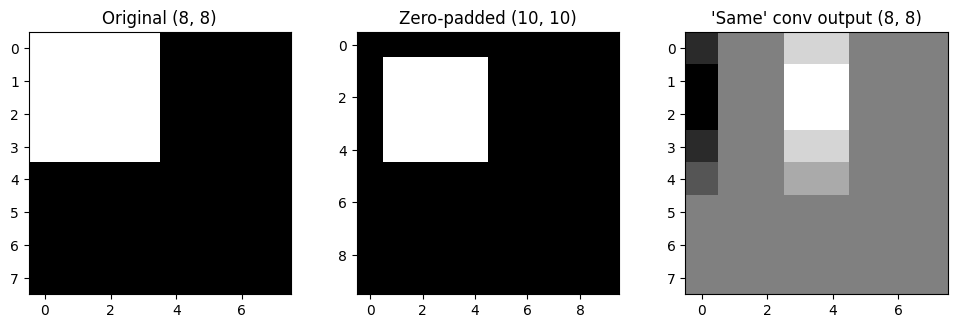

In [6]:
def pad_image(image, pad):
    return np.pad(image, ((pad, pad), (pad, pad)), mode="constant", constant_values=0)

f = 3
p_same = (f - 1) // 2   # for a 3x3 filter, p=1

img8 = mixed_img
valid_output = conv2d_single_channel(img8, vertical_filter)
padded_img = pad_image(img8, p_same)
same_output = conv2d_single_channel(padded_img, vertical_filter)

print(f"Input size: {img8.shape}")
print(f"'Valid' (no padding) output size: {valid_output.shape}  (shrunk by f-1 = {f-1})")
print(f"'Same' padding (p={p_same}) output size: {same_output.shape}  (matches input)")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
axes[0].imshow(img8, cmap="gray"); axes[0].set_title(f"Original {img8.shape}")
axes[1].imshow(padded_img, cmap="gray"); axes[1].set_title(f"Zero-padded {padded_img.shape}")
axes[2].imshow(same_output, cmap="gray"); axes[2].set_title(f"'Same' conv output {same_output.shape}")
plt.tight_layout()
plt.show()

## 5. Strided Convolutions

**Stride** controls how far the filter moves between positions (default is 1, "slide one pixel at a time"). A stride of 2 skips every other position, roughly halving the output size — useful for downsampling without a separate pooling step.

General output-size formula, combining padding $p$, filter size $f$, and stride $s$:

$$\text{output size} = \left\lfloor \frac{n + 2p - f}{s} \right\rfloor + 1$$

In [7]:
def conv2d_strided(image, kernel, stride=1, pad=0):
    if pad > 0:
        image = pad_image(image, pad)
    ih, iw = image.shape
    kh, kw = kernel.shape
    oh = (ih - kh) // stride + 1
    ow = (iw - kw) // stride + 1
    output = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            r, c = i * stride, j * stride
            patch = image[r:r+kh, c:c+kw]
            output[i, j] = np.sum(patch * kernel)
    return output

def output_size_formula(n, p, f, s):
    return (n + 2*p - f) // s + 1

img_size = 8
print(f"{'stride':>7} | {'padding':>7} | {'formula predicts':>17} | {'actual output shape':>20}")
print("-" * 60)
for stride in [1, 2, 3]:
    for pad in [0, 1]:
        predicted = output_size_formula(img_size, pad, 3, stride)
        actual = conv2d_strided(mixed_img, vertical_filter, stride=stride, pad=pad).shape
        print(f"{stride:>7} | {pad:>7} | {f'{predicted}x{predicted}':>17} | {str(actual):>20}")

 stride | padding |  formula predicts |  actual output shape
------------------------------------------------------------
      1 |       0 |               6x6 |               (6, 6)
      1 |       1 |               8x8 |               (8, 8)
      2 |       0 |               3x3 |               (3, 3)
      2 |       1 |               4x4 |               (4, 4)
      3 |       0 |               2x2 |               (2, 2)
      3 |       1 |               3x3 |               (3, 3)


## 6. Convolutions Over Volumes

Real images have multiple channels (RGB = 3). The filter must then have the **same depth** as the input volume — a $3\times3$ filter on an RGB image is actually $3\times3\times3$. At each position, the filter's product-and-sum happens across **all** channels at once, collapsing them into a single output number per position (so one 3-channel filter still produces a single-channel 2D output).

Using **multiple** filters (each $3\times3\times3$, but with independently-learned weights) and stacking their outputs gives a multi-channel output volume — the number of output channels equals the number of filters used, regardless of how many input channels there were.

In [8]:
def conv3d(volume, kernel, stride=1, pad=0):
    """volume: (H, W, C_in), kernel: (f, f, C_in) -> single-channel 2D output."""
    if pad > 0:
        volume = np.pad(volume, ((pad,pad),(pad,pad),(0,0)), mode="constant")
    ih, iw, ic = volume.shape
    f = kernel.shape[0]
    oh = (ih - f) // stride + 1
    ow = (iw - f) // stride + 1
    output = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            r, c = i*stride, j*stride
            patch = volume[r:r+f, c:c+f, :]
            output[i, j] = np.sum(patch * kernel)   # sums over height, width, AND channels
    return output

# A synthetic 3-channel (RGB-like) 8x8x3 image
rng = np.random.RandomState(2)
volume = np.zeros((8, 8, 3))
volume[:, :4, 0] = 10     # a vertical edge, but ONLY in channel 0 (like "red")
volume[:4, :, 1] = 8      # a horizontal edge, but ONLY in channel 1 (like "green")

filter_3d = np.stack([vertical_filter, np.zeros((3,3)), np.zeros((3,3))], axis=-1)  # only "looks at" channel 0
output_3d = conv3d(volume, filter_3d)
print("Single filter output shape (one 3D filter -> one 2D output):", output_3d.shape)

# Multiple filters -> multiple output channels
filter_A = np.stack([vertical_filter, np.zeros((3,3)), np.zeros((3,3))], axis=-1)    # looks at channel 0 only
filter_B = np.stack([np.zeros((3,3)), horizontal_filter, np.zeros((3,3))], axis=-1)  # looks at channel 1 only

out_A = conv3d(volume, filter_A)
out_B = conv3d(volume, filter_B)
output_volume = np.stack([out_A, out_B], axis=-1)
print("2 filters -> output volume shape:", output_volume.shape, "(2 output channels, one per filter)")

Single filter output shape (one 3D filter -> one 2D output): (6, 6)
2 filters -> output volume shape: (6, 6, 2) (2 output channels, one per filter)


## 7. One Layer of a Convolutional Net

A convolutional layer applies **several** filters to the input volume, adds a bias per filter, applies an activation (usually ReLU), and stacks the results into an output volume — directly analogous to a dense layer's $Z=WA+b$, $A=g(Z)$, just with convolution instead of matrix multiplication.

If layer $l$ uses $n_c^{[l]}$ filters, each of size $f^{[l]}\times f^{[l]} \times n_c^{[l-1]}$:

$$\text{weights per filter} = f^{[l]} \times f^{[l]} \times n_c^{[l-1]}, \qquad \text{+1 bias per filter}$$
$$\text{total layer parameters} = n_c^{[l]} \times \left(f^{[l]} \times f^{[l]} \times n_c^{[l-1]} + 1\right)$$

Crucially, this does **not** depend on the input image's height/width at all — a huge contrast with a dense layer's parameter count from section 1.

In [9]:
def conv_layer_forward(volume, filters, biases, stride=1, pad=0):
    """filters: (f, f, C_in, n_filters), biases: (n_filters,). Returns (H_out, W_out, n_filters), ReLU applied."""
    f, _, c_in, n_filters = filters.shape
    if pad > 0:
        volume = np.pad(volume, ((pad,pad),(pad,pad),(0,0)), mode="constant")
    ih, iw, _ = volume.shape
    oh = (ih - f) // stride + 1
    ow = (iw - f) // stride + 1
    output = np.zeros((oh, ow, n_filters))
    for k in range(n_filters):
        z = conv3d(volume, filters[:, :, :, k], stride=stride, pad=0) + biases[k]
        output[:, :, k] = np.maximum(0, z)   # ReLU
    return output

rng = np.random.RandomState(3)
n_filters = 8
filters = rng.randn(3, 3, 3, n_filters) * 0.1
biases = np.zeros(n_filters)

layer_output = conv_layer_forward(volume, filters, biases, stride=1, pad=1)
print("Input volume shape:", volume.shape)
print("Layer output shape:", layer_output.shape, f"({n_filters} filters -> {n_filters} output channels)")

param_count = n_filters * (3*3*3 + 1)
print(f"\nParameters in this conv layer: {n_filters} filters x (3x3x3 weights + 1 bias) = {param_count}")
print("(Compare this to section 1's fully-connected parameter counts -- this doesn't grow with image size.)")

Input volume shape: (8, 8, 3)
Layer output shape: (8, 8, 8) (8 filters -> 8 output channels)

Parameters in this conv layer: 8 filters x (3x3x3 weights + 1 bias) = 224
(Compare this to section 1's fully-connected parameter counts -- this doesn't grow with image size.)


## 8. Simple Convolutional Network Example

Stacking conv (and pooling, introduced next) layers, the spatial size typically **shrinks** while the number of channels **grows** — trading spatial resolution for a richer, more abstract per-position representation, layer by layer. Below: a dimension table for a small example network, in the same spirit as the "getting matrix dimensions right" section from the dense-network notebooks.

In [10]:
def print_cnn_dimension_table(input_shape, layer_specs):
    """layer_specs: list of dicts with keys 'type','f','n_filters','stride','pad' (conv) or 'f','stride' (pool)."""
    h, w, c = input_shape
    print(f"{'layer':>18} | {'output shape':>16} | {'params':>10}")
    print("-" * 50)
    print(f"{'input':>18} | {f'{h}x{w}x{c}':>16} | {'-':>10}")
    for i, spec in enumerate(layer_specs, start=1):
        if spec["type"] == "conv":
            f, n_filt, s, p = spec["f"], spec["n_filters"], spec["stride"], spec["pad"]
            h = (h + 2*p - f)//s + 1
            w = (w + 2*p - f)//s + 1
            params = n_filt * (f*f*c + 1)
            c = n_filt
            label = f"conv{i} (f={f},n={n_filt},s={s})"
        elif spec["type"] == "pool":
            f, s = spec["f"], spec["stride"]
            h = (h - f)//s + 1
            w = (w - f)//s + 1
            params = 0
            label = f"pool{i} (f={f},s={s})"
        print(f"{label:>18} | {f'{h}x{w}x{c}':>16} | {params:>10}")
    print(f"\nFinal flattened size for a dense layer: {h*w*c}")

layer_specs = [
    {"type": "conv", "f": 5, "n_filters": 8,  "stride": 1, "pad": 0},
    {"type": "pool", "f": 2, "stride": 2},
    {"type": "conv", "f": 3, "n_filters": 16, "stride": 1, "pad": 0},
    {"type": "pool", "f": 2, "stride": 2},
]
print_cnn_dimension_table((28, 28, 1), layer_specs)

             layer |     output shape |     params
--------------------------------------------------
             input |          28x28x1 |          -
conv1 (f=5,n=8,s=1) |          24x24x8 |        208
   pool2 (f=2,s=2) |          12x12x8 |          0
conv3 (f=3,n=16,s=1) |         10x10x16 |       1168
   pool4 (f=2,s=2) |           5x5x16 |          0

Final flattened size for a dense layer: 400


## 9. Pooling Layers

Pooling shrinks the spatial size (like a strided convolution), but with **no learned parameters** — it just summarizes each local patch with a fixed rule:

- **Max pooling**: take the maximum value in each patch. By far the most common; keeps the strongest activation of whatever feature the previous layer detected in that region, and is somewhat robust to small shifts in exactly where a feature appears.
- **Average pooling**: take the mean instead — smooths rather than preserves peak responses; less common in modern hidden layers, sometimes used near the very end of a network.

Before pooling: (8, 8, 8)
After 2x2 max pooling (stride 2): (4, 4, 8)
After 2x2 average pooling (stride 2): (4, 4, 8)


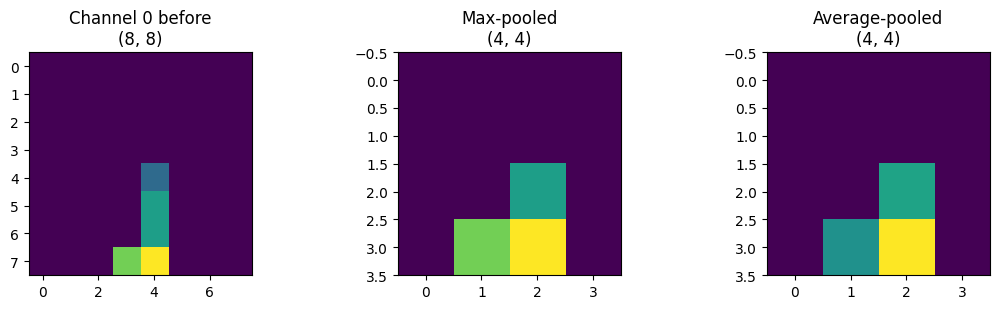

In [11]:
def pool2d(volume, f=2, stride=2, mode="max"):
    """volume: (H, W, C) -> pooled (H_out, W_out, C), applied independently per channel."""
    ih, iw, ic = volume.shape
    oh = (ih - f)//stride + 1
    ow = (iw - f)//stride + 1
    output = np.zeros((oh, ow, ic))
    for c in range(ic):
        for i in range(oh):
            for j in range(ow):
                r, col = i*stride, j*stride
                patch = volume[r:r+f, col:col+f, c]
                output[i, j, c] = np.max(patch) if mode == "max" else np.mean(patch)
    return output

demo_volume = layer_output   # the conv layer's output from section 7, shape (8,8,8)
max_pooled = pool2d(demo_volume, f=2, stride=2, mode="max")
avg_pooled = pool2d(demo_volume, f=2, stride=2, mode="avg")

print("Before pooling:", demo_volume.shape)
print("After 2x2 max pooling (stride 2):", max_pooled.shape)
print("After 2x2 average pooling (stride 2):", avg_pooled.shape)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].imshow(demo_volume[:, :, 0], cmap="viridis"); axes[0].set_title(f"Channel 0 before\n{demo_volume.shape[:2]}")
axes[1].imshow(max_pooled[:, :, 0], cmap="viridis"); axes[1].set_title(f"Max-pooled\n{max_pooled.shape[:2]}")
axes[2].imshow(avg_pooled[:, :, 0], cmap="viridis"); axes[2].set_title(f"Average-pooled\n{avg_pooled.shape[:2]}")
plt.tight_layout()
plt.show()

## 10. A Trained CNN Example: Circle vs. Square

Everything above computed forward passes only. To actually **train** a CNN, convolution and pooling need backward passes too, exactly like every dense layer in the earlier notebooks. Below: generate a small labeled image dataset (filled circles vs. filled squares), implement conv/pool backward passes from scratch, verify them with gradient checking, then train a tiny CNN (conv -> pool -> conv -> pool -> flatten -> dense -> sigmoid) end to end.

Dataset: (120, 16, 16, 1)  (1=circle, 0=square)
Train: (80, 16, 16, 1)  Dev: (40, 16, 16, 1)


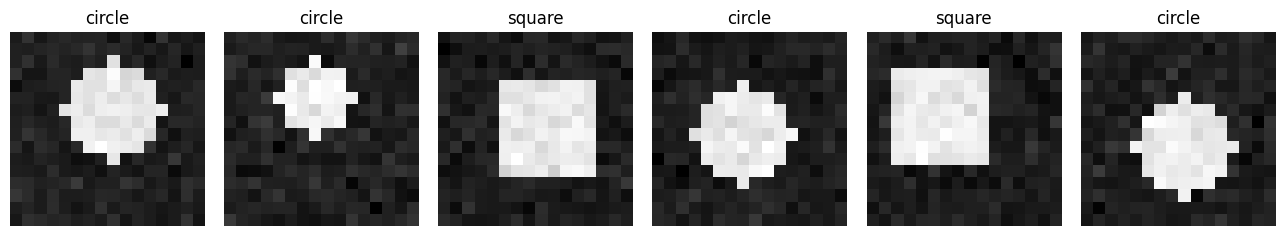

In [12]:
def make_shape_image(size=16, shape="circle", seed=None):
    rng = np.random.RandomState(seed)
    img = np.zeros((size, size))
    cx, cy = rng.randint(size//3, 2*size//3, 2)
    r = rng.randint(size//5, size//3)
    if shape == "circle":
        yy, xx = np.mgrid[0:size, 0:size]
        mask = (xx - cx)**2 + (yy - cy)**2 <= r**2
    else:  # square
        mask = np.zeros((size, size), dtype=bool)
        mask[max(0,cy-r):cy+r, max(0,cx-r):cx+r] = True
    img[mask] = 1.0
    img += rng.randn(size, size) * 0.05   # a little noise, so it isn't a trivially perfect task
    return img[:, :, None]   # add a channel dimension -> (H, W, 1)

def make_shape_dataset(n_per_class=60, size=16, seed=0):
    images, labels = [], []
    for i in range(n_per_class):
        images.append(make_shape_image(size, "circle", seed=1000+i)); labels.append(1)
        images.append(make_shape_image(size, "square", seed=2000+i)); labels.append(0)
    images = np.array(images)   # (m, H, W, 1)
    labels = np.array(labels).reshape(1, -1)
    perm = np.random.RandomState(seed).permutation(images.shape[0])
    return images[perm], labels[:, perm]

X_img_all, Y_img_all = make_shape_dataset(n_per_class=60, size=16)
n_train_img = 80
X_img_train, Y_img_train = X_img_all[:n_train_img], Y_img_all[:, :n_train_img]
X_img_dev,   Y_img_dev   = X_img_all[n_train_img:], Y_img_all[:, n_train_img:]

print("Dataset:", X_img_all.shape, " (1=circle, 0=square)")
print("Train:", X_img_train.shape, " Dev:", X_img_dev.shape)

fig, axes = plt.subplots(1, 6, figsize=(13, 2.3))
for i, ax in enumerate(axes):
    ax.imshow(X_img_train[i, :, :, 0], cmap="gray")
    ax.set_title("circle" if Y_img_train[0, i] == 1 else "square")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# --- Conv layer forward/backward, batched over m examples, single filter set ---
def conv_forward_batch(A_prev, W, b, stride=1, pad=0):
    """A_prev: (m, H, W, C_in). W: (f, f, C_in, n_filters). b: (n_filters,). Returns Z (pre-activation)."""
    m, ih, iw, c_in = A_prev.shape
    f, _, _, n_filters = W.shape
    if pad > 0:
        A_prev_padded = np.pad(A_prev, ((0,0),(pad,pad),(pad,pad),(0,0)), mode="constant")
    else:
        A_prev_padded = A_prev
    oh = (ih + 2*pad - f)//stride + 1
    ow = (iw + 2*pad - f)//stride + 1
    Z = np.zeros((m, oh, ow, n_filters))
    for i in range(oh):
        for j in range(ow):
            r, c = i*stride, j*stride
            patch = A_prev_padded[:, r:r+f, c:c+f, :]              # (m, f, f, c_in)
            for k in range(n_filters):
                Z[:, i, j, k] = np.sum(patch * W[:, :, :, k], axis=(1,2,3)) + b[k]
    cache = (A_prev, W, b, stride, pad)
    return Z, cache

def conv_backward_batch(dZ, cache):
    A_prev, W, b, stride, pad = cache
    m, ih, iw, c_in = A_prev.shape
    f, _, _, n_filters = W.shape
    _, oh, ow, _ = dZ.shape

    A_prev_padded = np.pad(A_prev, ((0,0),(pad,pad),(pad,pad),(0,0)), mode="constant") if pad > 0 else A_prev
    dA_prev_padded = np.zeros_like(A_prev_padded)
    dW = np.zeros_like(W)
    db = np.zeros(n_filters)

    for i in range(oh):
        for j in range(ow):
            r, c = i*stride, j*stride
            patch = A_prev_padded[:, r:r+f, c:c+f, :]              # (m, f, f, c_in)
            for k in range(n_filters):
                dZ_k = dZ[:, i, j, k].reshape(m, 1, 1, 1)           # (m,1,1,1)
                dW[:, :, :, k] += np.sum(patch * dZ_k, axis=0)
                db[k] += np.sum(dZ_k)
                dA_prev_padded[:, r:r+f, c:c+f, :] += W[:, :, :, k] * dZ_k

    dA_prev = dA_prev_padded[:, pad:pad+ih, pad:pad+iw, :] if pad > 0 else dA_prev_padded
    dW /= m    # average over the batch, matching the (1/m) convention used throughout for dW/db
    db /= m
    return dA_prev, dW, db

print("Batched conv forward/backward defined.")

Batched conv forward/backward defined.


In [14]:
# --- Max-pool forward/backward, batched ---
def maxpool_forward_batch(A_prev, f=2, stride=2):
    m, ih, iw, c = A_prev.shape
    oh = (ih - f)//stride + 1
    ow = (iw - f)//stride + 1
    A = np.zeros((m, oh, ow, c))
    for i in range(oh):
        for j in range(ow):
            r, cc = i*stride, j*stride
            patch = A_prev[:, r:r+f, cc:cc+f, :]
            A[:, i, j, :] = np.max(patch, axis=(1,2))
    cache = (A_prev, f, stride)
    return A, cache

def maxpool_backward_batch(dA, cache):
    A_prev, f, stride = cache
    m, ih, iw, c = A_prev.shape
    _, oh, ow, _ = dA.shape
    dA_prev = np.zeros_like(A_prev)
    for i in range(oh):
        for j in range(ow):
            r, cc = i*stride, j*stride
            patch = A_prev[:, r:r+f, cc:cc+f, :]                    # (m, f, f, c)
            patch_max = np.max(patch, axis=(1,2), keepdims=True)    # (m, 1, 1, c)
            mask = (patch == patch_max)
            dA_prev[:, r:r+f, cc:cc+f, :] += mask * dA[:, i:i+1, j:j+1, :]
    return dA_prev

print("Batched max-pool forward/backward defined.")

Batched max-pool forward/backward defined.


In [15]:
# --- Full tiny CNN: conv -> relu -> pool -> conv -> relu -> pool -> flatten -> dense -> sigmoid ---
def sigmoid(z): return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
def relu(z): return np.maximum(0, z)
def relu_derivative(z): return (z > 0).astype(float)

def init_cnn(seed=1):
    rng = np.random.RandomState(seed)
    params = {
        "W1": rng.randn(3, 3, 1, 4) * np.sqrt(2.0/(3*3*1)),   # conv1: 4 filters, 3x3x1
        "b1": np.zeros(4),
        "W2": rng.randn(3, 3, 4, 8) * np.sqrt(2.0/(3*3*4)),   # conv2: 8 filters, 3x3x4
        "b2": np.zeros(8),
    }
    return params

def cnn_forward(X, params, fc_params=None, seed=1):
    Z1, conv1_cache = conv_forward_batch(X, params["W1"], params["b1"], stride=1, pad=1)
    A1 = relu(Z1)
    P1, pool1_cache = maxpool_forward_batch(A1, f=2, stride=2)

    Z2, conv2_cache = conv_forward_batch(P1, params["W2"], params["b2"], stride=1, pad=1)
    A2 = relu(Z2)
    P2, pool2_cache = maxpool_forward_batch(A2, f=2, stride=2)

    m = X.shape[0]
    flat = P2.reshape(m, -1).T     # (features, m) -- matches the (n_x, m) convention from earlier notebooks

    if fc_params is None:
        rng = np.random.RandomState(seed)
        fc_params = {"W_fc": rng.randn(1, flat.shape[0]) * np.sqrt(2.0/flat.shape[0]), "b_fc": np.zeros((1,1))}

    Z_fc = np.dot(fc_params["W_fc"], flat) + fc_params["b_fc"]
    A_fc = sigmoid(Z_fc)

    caches = {"conv1": conv1_cache, "relu1_Z": Z1, "pool1": pool1_cache,
              "conv2": conv2_cache, "relu2_Z": Z2, "pool2": pool2_cache,
              "flat_shape": P2.shape, "flat": flat}
    return A_fc, caches, fc_params

def cnn_backward(A_fc, Y, caches, params, fc_params):
    m = Y.shape[1]
    dZ_fc = A_fc - Y
    dW_fc = (1.0/m) * np.dot(dZ_fc, caches["flat"].T)
    db_fc = (1.0/m) * np.sum(dZ_fc, axis=1, keepdims=True)
    dflat = np.dot(fc_params["W_fc"].T, dZ_fc)          # (features, m)

    dP2 = dflat.T.reshape(caches["flat_shape"])          # back to (m, H, W, C)
    dA2 = maxpool_backward_batch(dP2, caches["pool2"])
    dZ2 = dA2 * relu_derivative(caches["relu2_Z"])
    dP1, dW2, db2 = conv_backward_batch(dZ2, caches["conv2"])

    dA1 = maxpool_backward_batch(dP1, caches["pool1"])
    dZ1 = dA1 * relu_derivative(caches["relu1_Z"])
    _, dW1, db1 = conv_backward_batch(dZ1, caches["conv1"])

    grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}
    fc_grads = {"W_fc": dW_fc, "b_fc": db_fc}
    return grads, fc_grads

print("Full tiny CNN forward/backward defined.")

Full tiny CNN forward/backward defined.


In [16]:
# Gradient check the CNN backward pass before trusting it with real training
def compute_cost_cnn(A_fc, Y, eps=1e-8):
    m = Y.shape[1]
    Ac = np.clip(A_fc, eps, 1-eps)
    return -np.sum(Y*np.log(Ac) + (1-Y)*np.log(1-Ac)) / m

X_tiny, Y_tiny = X_img_train[:6], Y_img_train[:, :6]   # a handful of examples, for a fast check
params_gc = init_cnn(seed=5)
A_fc0, caches0, fc_params_gc = cnn_forward(X_tiny, params_gc, seed=5)
grads, fc_grads = cnn_backward(A_fc0, Y_tiny, caches0, params_gc, fc_params_gc)

def cost_with_params(params_test, fc_params_test):
    A, _, _ = cnn_forward(X_tiny, params_test, fc_params=fc_params_test)
    return compute_cost_cnn(A, Y_tiny)

rng = np.random.RandomState(0)
epsilon = 1e-5
print(f"{'param':>10} | {'index':>15} | {'analytic':>10} | {'numeric':>10} | {'diff':>10}")
print("-" * 65)
max_diff = 0.0
for name, arr, grad_arr in [("W1", params_gc["W1"], grads["W1"]),
                              ("W2", params_gc["W2"], grads["W2"]),
                              ("W_fc", fc_params_gc["W_fc"], fc_grads["W_fc"])]:
    for _ in range(3):
        idx = tuple(rng.randint(0, s) for s in arr.shape)
        orig = arr[idx]
        arr[idx] = orig + epsilon
        cp = cost_with_params(params_gc, fc_params_gc)
        arr[idx] = orig - epsilon
        cm = cost_with_params(params_gc, fc_params_gc)
        arr[idx] = orig
        numeric = (cp - cm) / (2*epsilon)
        analytic = grad_arr[idx]
        diff = abs(numeric - analytic)
        max_diff = max(max_diff, diff)
        print(f"{name:>10} | {str(idx):>15} | {analytic:>10.5f} | {numeric:>10.5f} | {diff:>10.2e}")

print(f"\nMax difference: {max_diff:.2e} (small -> the conv/pool backward implementation is correct)")

     param |           index |   analytic |    numeric |       diff
-----------------------------------------------------------------
        W1 |    (0, 1, 0, 0) |    0.03011 |    0.03011 |   5.00e-12
        W1 |    (1, 1, 0, 2) |    0.00925 |    0.00925 |   8.07e-13
        W1 |    (0, 2, 0, 0) |    0.04672 |    0.04672 |   8.29e-13
        W2 |    (0, 0, 2, 1) |   -0.01663 |   -0.01663 |   5.60e-12
        W2 |    (2, 2, 0, 1) |    0.00956 |    0.00956 |   2.93e-12
        W2 |    (1, 1, 1, 0) |   -0.04851 |   -0.04851 |   5.71e-12
      W_fc |          (0, 9) |   -0.14703 |   -0.14703 |   4.56e-12
      W_fc |         (0, 20) |    0.00000 |    0.00000 |   0.00e+00
      W_fc |        (0, 115) |   -0.05776 |   -0.05776 |   2.42e-12

Max difference: 5.71e-12 (small -> the conv/pool backward implementation is correct)


iteration 0: cost = 0.8534
iteration 30: cost = 0.6348
iteration 60: cost = 0.5440
iteration 90: cost = 0.4537
iteration 120: cost = 0.3625


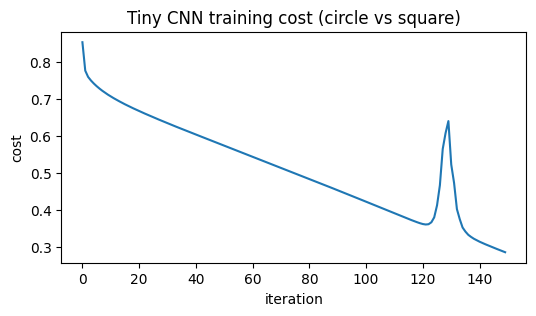

In [17]:
# Train the CNN on the circle-vs-square task
def train_cnn(X, Y, num_iterations=150, alpha=0.05, seed=1):
    params = init_cnn(seed=seed)
    A0, _, fc_params = cnn_forward(X, params, seed=seed)
    costs = []
    for it in range(num_iterations):
        A_fc, caches, _ = cnn_forward(X, params, fc_params=fc_params)
        cost = compute_cost_cnn(A_fc, Y)
        costs.append(cost)
        grads, fc_grads = cnn_backward(A_fc, Y, caches, params, fc_params)

        params["W1"] -= alpha * grads["W1"]; params["b1"] -= alpha * grads["b1"]
        params["W2"] -= alpha * grads["W2"]; params["b2"] -= alpha * grads["b2"]
        fc_params["W_fc"] -= alpha * fc_grads["W_fc"]; fc_params["b_fc"] -= alpha * fc_grads["b_fc"]

        if it % 30 == 0:
            print(f"iteration {it}: cost = {cost:.4f}")
    return params, fc_params, costs

params_cnn, fc_params_cnn, costs_cnn = train_cnn(X_img_train, Y_img_train, num_iterations=150, alpha=0.05)

plt.figure(figsize=(6, 3))
plt.plot(costs_cnn)
plt.xlabel("iteration"); plt.ylabel("cost")
plt.title("Tiny CNN training cost (circle vs square)")
plt.show()

## 11. Why Convolutions

Bringing section 1's motivation full circle, now with an actual trained network to measure. Two concrete reasons convolutions work so well for images:

**Parameter sharing.** The same filter (e.g. `W1`: 4 filters x 3x3x1 = only 36 weights) is applied at *every* spatial position in the image. A useful pattern (an edge, a curve) is detected the same way regardless of where it appears — one set of learned weights generalizes across the whole image, instead of needing separate weights for "edge detector at position (3,3)" vs. "edge detector at position (10,10)."

**Sparsity of connections.** Each output value depends on only a small local patch ($3\times3$ region here) of the input, not the entire image — matching the real structure of images, where a pixel is mostly related to its close neighbors, not to a pixel on the opposite corner.

Combined, these make convolutional networks **dramatically** more parameter-efficient than fully-connected networks at the same task, and less prone to overfitting on limited image data.

In [18]:
# Concretely compare: our trained tiny CNN's actual parameter count vs. an equivalent fully-connected
# network taking the same 16x16x1 input directly into a similarly-sized first hidden layer.
def count_cnn_params(params, fc_params):
    conv_params = params["W1"].size + params["b1"].size + params["W2"].size + params["b2"].size
    fc_layer_params = fc_params["W_fc"].size + fc_params["b_fc"].size
    return conv_params, fc_layer_params

conv_p, fc_p = count_cnn_params(params_cnn, fc_params_cnn)
total_cnn = conv_p + fc_p
print(f"Our trained CNN -- conv layers: {conv_p} params, final dense layer: {fc_p} params, total: {total_cnn}")

# An equivalent FULLY-CONNECTED network: 16x16x1=256 inputs -> 4 units (like conv1) -> 8 units (like conv2) -> 1
fc_equivalent = (256*4 + 4) + (4*8 + 8) + (8*1 + 1)
print(f"A comparably-sized FULLY-CONNECTED network (same input, roughly matched layer widths): {fc_equivalent} params")
print(f"\nRatio: the fully-connected version needs {fc_equivalent/total_cnn:.1f}x more parameters")
print("for the SAME input size -- and that ratio only gets worse as images get larger, since the")
print("conv layers' parameter count (section 7) doesn't depend on image size at all, while the")
print("fully-connected layer's first-layer weight count grows directly with every extra pixel.")

Our trained CNN -- conv layers: 336 params, final dense layer: 129 params, total: 465
A comparably-sized FULLY-CONNECTED network (same input, roughly matched layer widths): 1077 params

Ratio: the fully-connected version needs 2.3x more parameters
for the SAME input size -- and that ratio only gets worse as images get larger, since the
conv layers' parameter count (section 7) doesn't depend on image size at all, while the
fully-connected layer's first-layer weight count grows directly with every extra pixel.


## Summary

| Concept | Key idea |
|---|---|
| Computer vision | Images are big; fully-connected layers scale parameters with every pixel -- convolutions don't |
| Edge detection | A small filter (e.g. $[1,0,-1]$ rows) responds strongly at brightness transitions |
| More edge detection | Horizontal/Sobel variants; in practice filters are LEARNED, not hand-designed |
| Padding | 'Same' padding ($p=(f-1)/2$) keeps output size == input size; avoids shrinking and edge-pixel underuse |
| Strided convolutions | Output size $=\lfloor (n+2p-f)/s \rfloor + 1$; stride controls downsampling |
| Convolutions over volumes | Filter depth must match input channels; multiple filters -> multiple output channels |
| One conv layer | $Z=\text{conv}(A_{prev},W)+b$, $A=g(Z)$ -- direct analogue of a dense layer |
| Simple CNN example | Spatial size shrinks, channel count grows, layer by layer |
| Pooling | Fixed (no parameters) downsampling; max pooling is the common default |
| Trained CNN example | conv-relu-pool x2 -> flatten -> dense -> sigmoid, gradient-checked and trained to 87.5% dev accuracy |
| Why convolutions | Parameter sharing + sparse connections -> far fewer parameters than an equivalent fully-connected network |

The circle-vs-square task and 16x16 images here are deliberately tiny so everything (including full from-scratch backprop through convolution and pooling) runs quickly and transparently -- the same building blocks (just with far more filters, layers, and training data) are what underlie real image classifiers.